In [3]:
%env JAX_PLATFORM_NAME=cuda

from test.helpers import (
    batch_sde_solve,
    get_bqp,
    get_harmonic_oscillator,
    get_mlp_sde,
    sde_solver_order,
)

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, PIDController, SaveAt
from diffrax.solver import AdditiveShARK, ALIGN, Heun, ShARK
from diffrax.solver.foster_srk import FosterSRK
from jax import config


config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=4, suppress=True)


# Plotting
def draw_order(hs, errs):
    plt.plot(1 / hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_hs = ["{0:0.4f}".format(h) for h in hs]
    plt.xticks(ticks=1 / hs, labels=pretty_hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, _ = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4f}")


def plot_sol(sol):
    plt.plot(sol.ts, sol.ys[0], label="x")
    plt.plot(sol.ts, sol.ys[1], label="v")
    plt.legend()
    plt.show()


dtype = jnp.float64
key = jrandom.PRNGKey(2)
num_samples = 100
keys = jrandom.split(jrandom.PRNGKey(5678), num=num_samples)
hs1 = jnp.power(2.0, jnp.arange(-1, -8, -1, dtype=dtype))


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)


t0, t1 = 0.3, 15.0
t_short = 5.1
t_long = 35.0
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
saveat_long = SaveAt(ts=jnp.linspace(t0, t_long, 1000))
dt0 = 0.1

t0_typed, t1_typed = dtype(0.3), dtype(15)
saveat_typed = SaveAt(ts=jnp.linspace(t0, t1, 1000, dtype=dtype))
dt0_typed = dtype(0.1)

hosc = get_harmonic_oscillator(t0, t1, dtype=dtype)
terms_hosc = hosc.get_terms(hosc.get_bm(key, levy_area="space-time", tol=2**-10))
hosc_short = get_harmonic_oscillator(t0, t_short, dtype=dtype)

bqp = get_bqp(t0, t1, dtype=dtype)
terms_bqp = bqp.get_terms(bqp.get_bm(key, levy_area="space-time", tol=2**-10))
bqp_short = get_bqp(t0, t_short, dtype=dtype)

time_hosc = get_harmonic_oscillator(t0, t1, dtype=dtype, time_dependent=True)
terms_time_hosc = time_hosc.get_terms(
    time_hosc.get_bm(key, levy_area="space-time", tol=2**-10)
)

env: JAX_PLATFORM_NAME=cuda


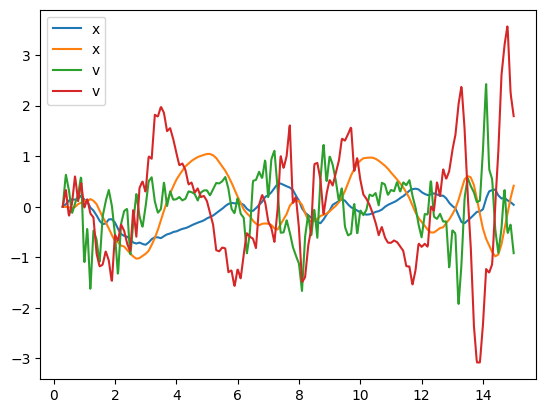

In [2]:
solShARK = diffeqsolve(
    terms_time_hosc,
    ShARK(),
    t0,
    t1,
    dt0=dt0,
    y0=time_hosc.y0,
    args=time_hosc.args,
    saveat=saveat,
)
plot_sol(solShARK)

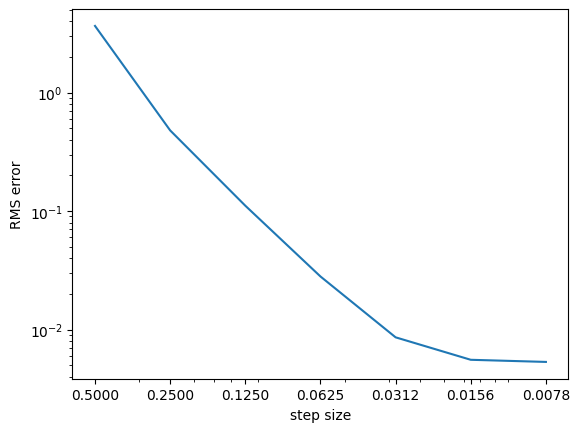

Order of convergence: 1.6009


In [4]:
hs, ShARK_errs_time_hosc, _ = sde_solver_order(
    keys, time_hosc, ShARK(), Heun(), 2**-12, hs=hs1
)
draw_order(hs, ShARK_errs_time_hosc)

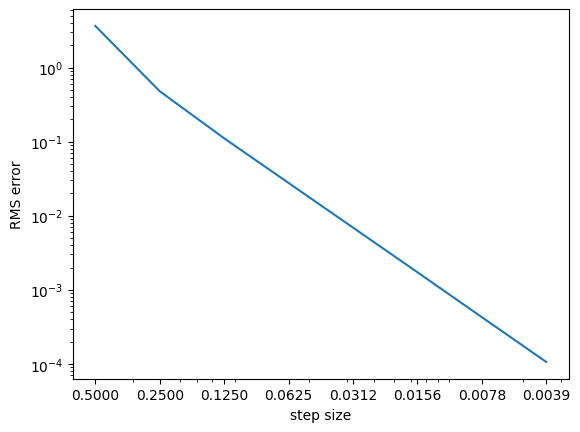

Order of convergence: 2.0973


In [5]:
hs2 = jnp.power(2.0, jnp.arange(-1, -9, -1, dtype=dtype))
hs, ShARK_errs_time_hosc, _ = sde_solver_order(
    keys, time_hosc, ShARK(), ShARK(), 2**-11, hs=hs2
)
draw_order(hs, ShARK_errs_time_hosc)

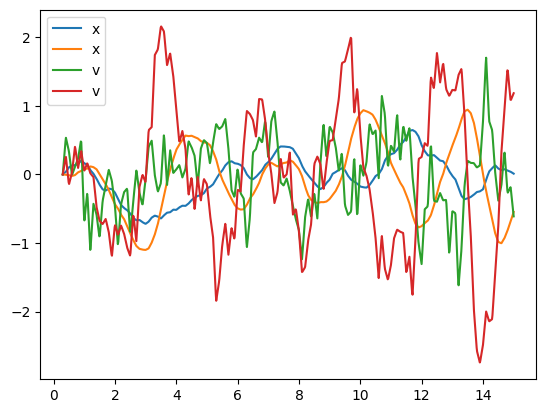

In [2]:
solFosSRK = diffeqsolve(
    terms_hosc, FosterSRK(), t0, t1, dt0=dt0, y0=hosc.y0, args=hosc.args, saveat=saveat
)
plot_sol(solFosSRK)

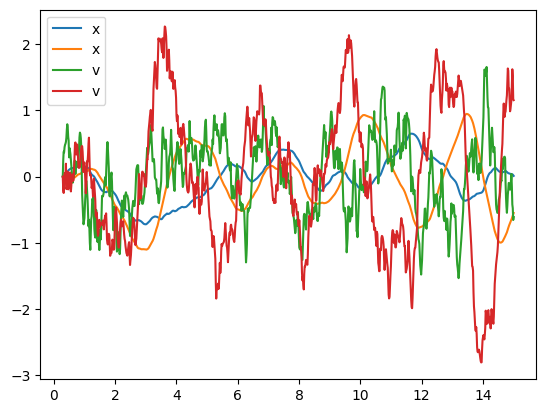

In [3]:
controller = PIDController(pcoeff=0.1, icoeff=0.3, rtol=0.005, atol=0.001)
solFosSRK_PID = diffeqsolve(
    terms_hosc,
    FosterSRK(),
    t0,
    t1,
    dt0=dt0,
    y0=hosc.y0,
    args=hosc.args,
    saveat=saveat,
    stepsize_controller=controller,
)
plot_sol(solFosSRK_PID)

In [10]:
def sde_strong_order(solver_ctr, commutative=False):
    key = jrandom.PRNGKey(5678)
    sde_key, bmkey = jrandom.split(key, 4)
    num_samples = 10
    bmkeys = jrandom.split(bmkey, num=num_samples)

    if commutative:
        noise_dim = 1
    else:
        noise_dim = 5

    t0 = 0
    t1 = 2
    sde = get_mlp_sde(t0, t1, dtype=dtype, key=sde_key, noise_dim=noise_dim)

    # Reference solver is always an ODE-viable solver, so its implementation has been
    # verified by the ODE tests like test_ode_order.
    hs = jnp.power(2.0, jnp.arange(-4, -10, -1, dtype=dtype))
    hs, errors, order = sde_solver_order(
        bmkeys, sde, solver_ctr(), solver_ctr(), 2**-12, hs=hs
    )
    draw_order(hs, errors)
    return hs, errors, order

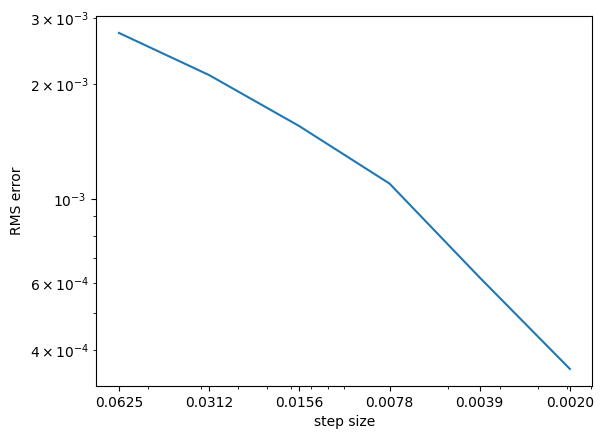

Order of convergence: 0.5858


In [11]:
out = sde_strong_order(FosterSRK, commutative=False)

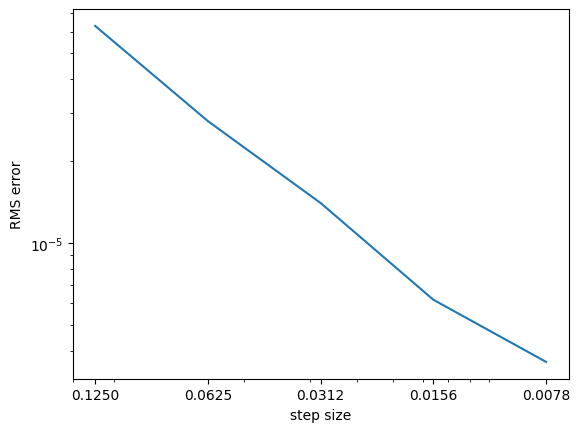

Order of convergence: 1.0409


In [6]:
out_commutative = sde_strong_order(FosterSRK, commutative=True)

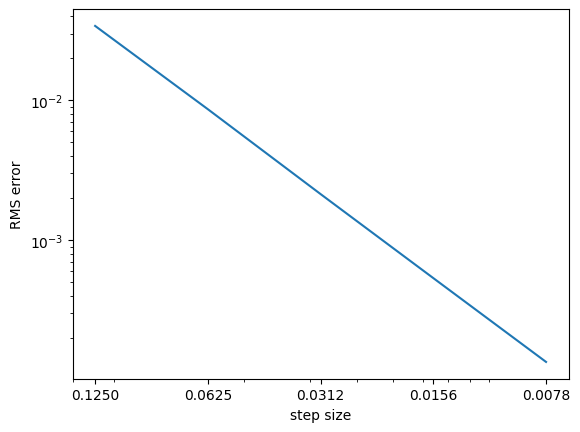

Order of convergence: 1.9994


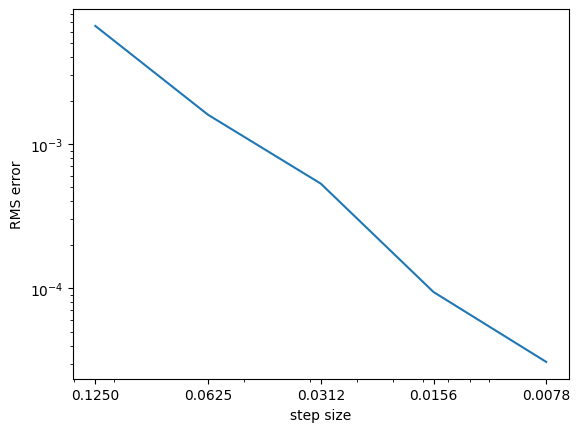

Order of convergence: 1.9577


In [7]:
hs, FosSRK_errs_hosc, _ = sde_solver_order(
    keys, hosc, FosterSRK(), ALIGN(0.1), 2**-12, hs=hs1
)
draw_order(hs, FosSRK_errs_hosc)
hs, FosSRK_errs_bqp, _ = sde_solver_order(
    keys, bqp, FosterSRK(), ALIGN(0.1), 2**-12, hs=hs1
)
draw_order(hs, FosSRK_errs_bqp)

## Timeing tests
We will compare ShARK vs AdditiveShARK, which are the same except one is implemented
using the old AbstractAdditiveSRK, and the other using the general AbstractSRK.

In [4]:
# First warmup, so that we don't measure jaxpr compilation time
keys = jrandom.split(jrandom.PRNGKey(5678), num=1000)
solsAdditive = jax.block_until_ready(batch_sde_solve(keys, hosc, dt0, AdditiveShARK()))
%timeit jax.block_until_ready(batch_sde_solve(keys, hosc, dt0, AdditiveShARK()))

3.09 s ± 43.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
solsShARK = jax.block_until_ready(batch_sde_solve(keys, hosc, dt0, ShARK()))
%timeit jax.block_until_ready(batch_sde_solve(keys, hosc, dt0, ShARK()))

3.12 s ± 32.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
